## Loading the Data

In [1]:
import pandas as pd

# loading the dataset
dataset_file = "StateAndCategory.csv"
df = pd.read_csv(dataset_file)
df.head()

,Date,State,Category,Variable,Value
0,2019-10-06,Alabama,Alcohol,Dollars,23611285.0
1,2019-10-13,Alabama,Alcohol,Dollars,23220758.0
2,2019-10-20,Alabama,Alcohol,Dollars,21770283.0
3,2019-10-27,Alabama,Alcohol,Dollars,21956558.0
4,2019-11-03,Alabama,Alcohol,Dollars,23183482.0


## Checking the Data

In [2]:
import pandas as pd

# checking the dataset shape and columns
print("Rows and columns:", df.shape)

column_info = pd.DataFrame({
    "Column": df.columns,
    "Data type": df.dtypes.astype(str).values
})
display(column_info)

print("Duplicate rows:", df.duplicated().sum())

Rows and columns: (889240, 5)


,Column,Data type
0,Date,object
1,State,object
2,Category,object
3,Variable,object
4,Value,float64


Duplicate rows: 0


In [3]:
import pandas as pd

# checking missing values and sales measures
missing_values = df.isna().sum().reset_index()
missing_values.columns = ["Column", "Missing values"]
display(missing_values)

variable_counts = df["Variable"].value_counts().rename_axis("Variable").reset_index(name="Rows")
display(variable_counts)

,Column,Missing values
0,Date,0
1,State,0
2,Category,0
3,Variable,0
4,Value,199066


,Variable,Rows
0,Dollars,88924
1,Unit sales,88924
2,Dollars last year,88924
3,Unit sales last year,88924
4,Dollars 3 years ago,88924
5,Unit sales 3 years ago,88924
6,Percent change dollars 1 year,88924
7,Percent change units 1 year,88924
8,Percent change dollars 3 years,88924
9,Percent change units 3 years,88924


In [4]:
import pandas as pd

# checking the time coverage
df["Date"] = pd.to_datetime(df["Date"])

dataset_summary = pd.DataFrame({
    "Item": [
        "First week",
        "Last week",
        "Number of weeks",
        "Number of states",
        "Number of categories",
        "Number of sales measures"
    ],
    "Value": [
        df["Date"].min().date(),
        df["Date"].max().date(),
        df["Date"].nunique(),
        df["State"].nunique(),
        df["Category"].nunique(),
        df["Variable"].nunique()
    ]
})

display(dataset_summary)

,Item,Value
0,First week,2019-10-06
1,Last week,2023-05-07
2,Number of weeks,188
3,Number of states,43
4,Number of categories,11
5,Number of sales measures,10


## Forecasting Task

In [5]:
import pandas as pd

# defining the modelling task
task_summary = pd.DataFrame({
    "Item": [
        "Project type",
        "Forecasting task",
        "Target variable",
        "Forecast horizon",
        "Target handling",
        "Data leakage rule"
    ],
    "Value": [
        "Time-series regression",
        "Weekly retail food demand forecasting",
        "Unit sales",
        "One-week-ahead forecasting",
        "Missing actual targets are not interpolated for final metrics",
        "Only calendar, state/category and past lagged sales features are used"
    ]
})

display(task_summary)

,Item,Value
0,Project type,Time-series regression
1,Forecasting task,Weekly retail food demand forecasting
2,Target variable,Unit sales
3,Forecast horizon,One-week-ahead forecasting
4,Target handling,Missing actual targets are not interpolated fo...
5,Data leakage rule,"Only calendar, state/category and past lagged ..."


## Preparing Unit Sales Data

In [6]:
import pandas as pd

# reshaping the dataset so the sales measures become columns
wide_df = df.pivot_table(
    index=["Date", "State", "Category"],
    columns="Variable",
    values="Value",
    aggfunc="first"
).reset_index()

wide_df.columns.name = None

# keeping only the target and identifiers for modelling
unit_df = wide_df[["Date", "State", "Category", "Unit sales"]].copy()
unit_df = unit_df.rename(columns={"Unit sales": "unit_sales"})
unit_df = unit_df.sort_values(["State", "Category", "Date"]).reset_index(drop=True)

print("Rows after reshaping:", unit_df.shape[0])
print("Columns after reshaping:", unit_df.shape[1])
unit_df.head()

Rows after reshaping: 88924
Columns after reshaping: 4


,Date,State,Category,unit_sales
0,2019-10-06,Alabama,Alcohol,2974221.0
1,2019-10-13,Alabama,Alcohol,2895573.0
2,2019-10-20,Alabama,Alcohol,2730939.0
3,2019-10-27,Alabama,Alcohol,2764970.0
4,2019-11-03,Alabama,Alcohol,2872683.0


In [7]:
import pandas as pd

# checking the target without filling missing actual values
series_lengths = unit_df.groupby(["State", "Category"]).size()

target_checks = pd.DataFrame({
    "Check": [
        "Unit sales rows",
        "Missing Unit sales",
        "Zero Unit sales",
        "Negative Unit sales",
        "State-category series",
        "Minimum weeks per series",
        "Maximum weeks per series"
    ],
    "Value": [
        len(unit_df),
        unit_df["unit_sales"].isna().sum(),
        (unit_df["unit_sales"] == 0).sum(),
        (unit_df["unit_sales"] < 0).sum(),
        unit_df.groupby(["State", "Category"]).ngroups,
        series_lengths.min(),
        series_lengths.max()
    ]
})

display(target_checks)

,Check,Value
0,Unit sales rows,88924
1,Missing Unit sales,13
2,Zero Unit sales,0
3,Negative Unit sales,0
4,State-category series,473
5,Minimum weeks per series,188
6,Maximum weeks per series,188


In [8]:
import pandas as pd

# checking where the actual target is missing
missing_targets = unit_df[unit_df["unit_sales"].isna()][["Date", "State", "Category", "unit_sales"]]
display(missing_targets)

print("These rows are kept as missing actual targets and are excluded from final metrics.")

,Date,State,Category,unit_sales
13859,2022-05-08,Florida,"Meats, eggs, and nuts",NaN
13870,2022-07-24,Florida,"Meats, eggs, and nuts",NaN
13878,2022-09-18,Florida,"Meats, eggs, and nuts",NaN
62768,2022-11-27,Pennsylvania,Dairy,NaN
62769,2022-12-04,Pennsylvania,Dairy,NaN
62771,2022-12-18,Pennsylvania,Dairy,NaN
62777,2023-01-29,Pennsylvania,Dairy,NaN
62778,2023-02-05,Pennsylvania,Dairy,NaN
62779,2023-02-12,Pennsylvania,Dairy,NaN
62780,2023-02-19,Pennsylvania,Dairy,NaN


These rows are kept as missing actual targets and are excluded from final metrics.


## Exploratory Data Analysis

In [9]:
import pandas as pd

# checking summary statistics for actual unit sales
summary_stats = unit_df["unit_sales"].describe().round(2).reset_index()
summary_stats.columns = ["Statistic", "Unit sales"]
display(summary_stats)

# checking total sales by state
top_states = (
    unit_df.dropna(subset=["unit_sales"])
    .groupby("State")["unit_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
display(top_states)

# checking total sales by category
category_sales = (
    unit_df.dropna(subset=["unit_sales"])
    .groupby("Category")["unit_sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
display(category_sales)

,Statistic,Unit sales
0,count,8.891100e+04
1,mean,9.319661e+06
2,std,1.502147e+07
3,min,4.437000e+03
4,25%,1.210617e+06
5,50%,4.253587e+06
6,75%,1.064809e+07
7,max,2.225147e+08


,State,unit_sales
0,California,7.812359e+10
1,Texas,7.476996e+10
2,Florida,6.384545e+10
3,New York,4.010387e+10
4,Pennsylvania,3.296055e+10
5,Ohio,3.271168e+10
6,North Carolina,3.229853e+10
7,Georgia,3.186468e+10
8,Illinois,2.976988e+10
9,Michigan,2.742233e+10


,Category,unit_sales
0,Commercially prepared items,2.756076e+11
1,Beverages,1.490482e+11
2,Vegetables,9.054257e+10
3,"Meats, eggs, and nuts",8.345056e+10
4,Dairy,6.781690e+10
5,Fruits,5.663689e+10
6,Grains,4.713146e+10
7,Alcohol,2.830864e+10
8,Other,1.877625e+10
9,Fats and oils,7.984617e+09


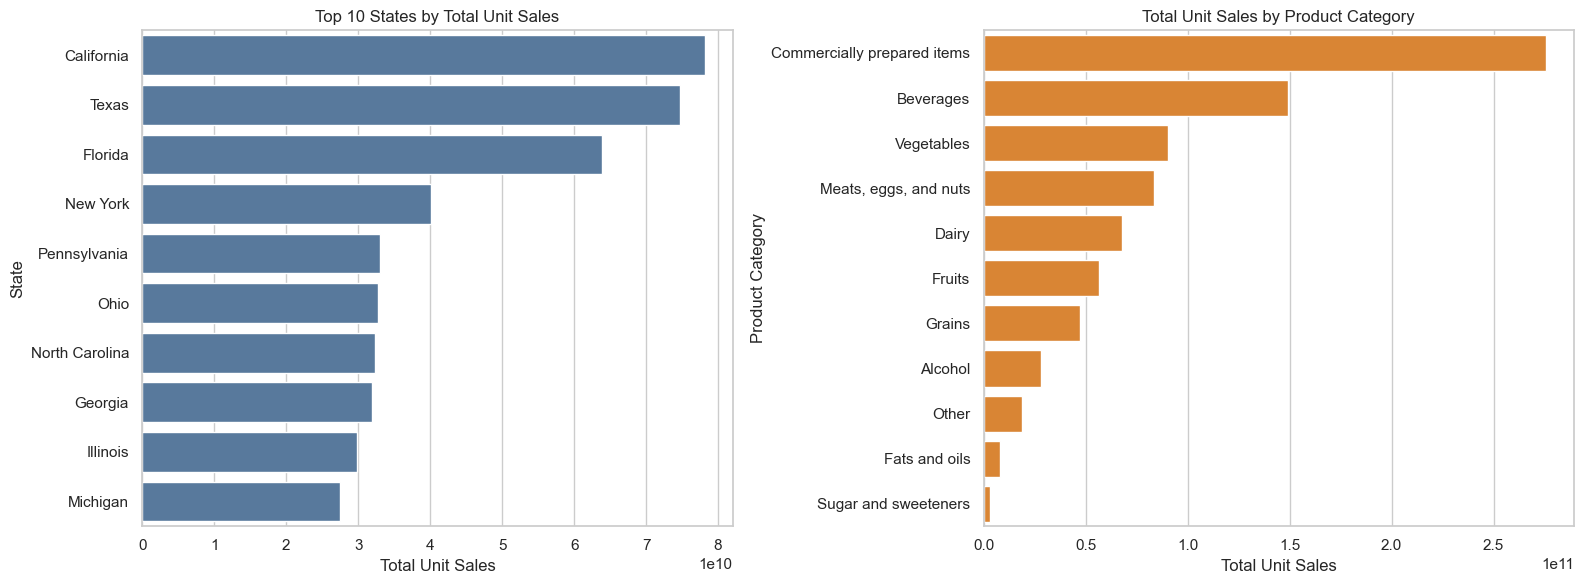

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# creating bar charts for demand by state and category
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_states, y="State", x="unit_sales", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top 10 States by Total Unit Sales")
axes[0].set_xlabel("Total Unit Sales")
axes[0].set_ylabel("State")

sns.barplot(data=category_sales, y="Category", x="unit_sales", ax=axes[1], color="#F58518")
axes[1].set_title("Total Unit Sales by Product Category")
axes[1].set_xlabel("Total Unit Sales")
axes[1].set_ylabel("Product Category")

plt.tight_layout()
plt.show()

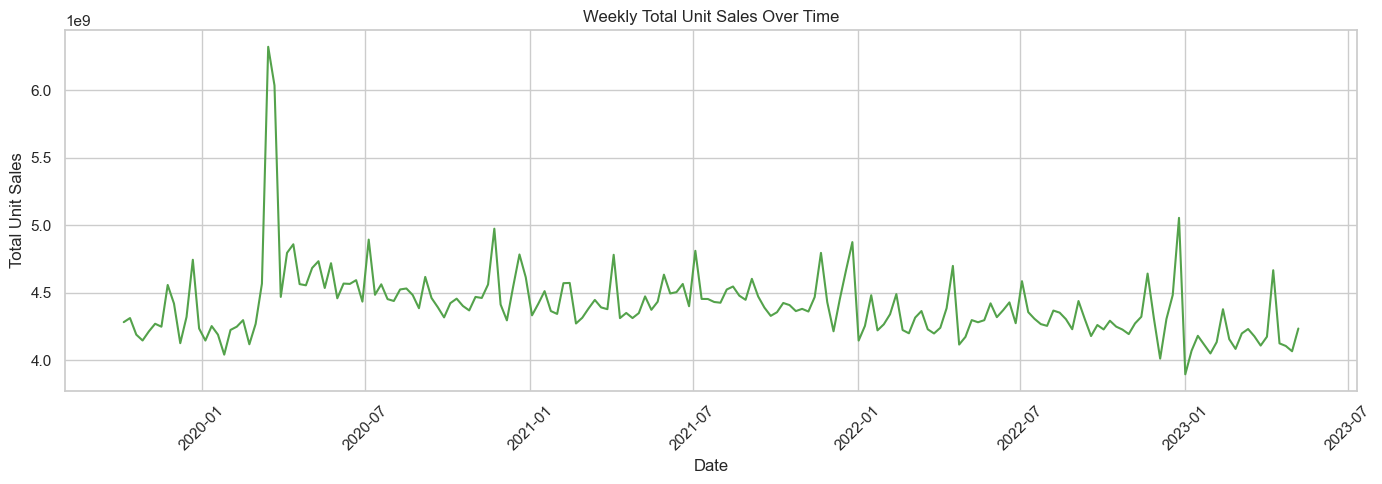

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# plotting weekly total demand over time
weekly_sales = (
    unit_df.dropna(subset=["unit_sales"])
    .groupby("Date")["unit_sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))
sns.lineplot(data=weekly_sales, x="Date", y="unit_sales", color="#54A24B")
plt.title("Weekly Total Unit Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Unit Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

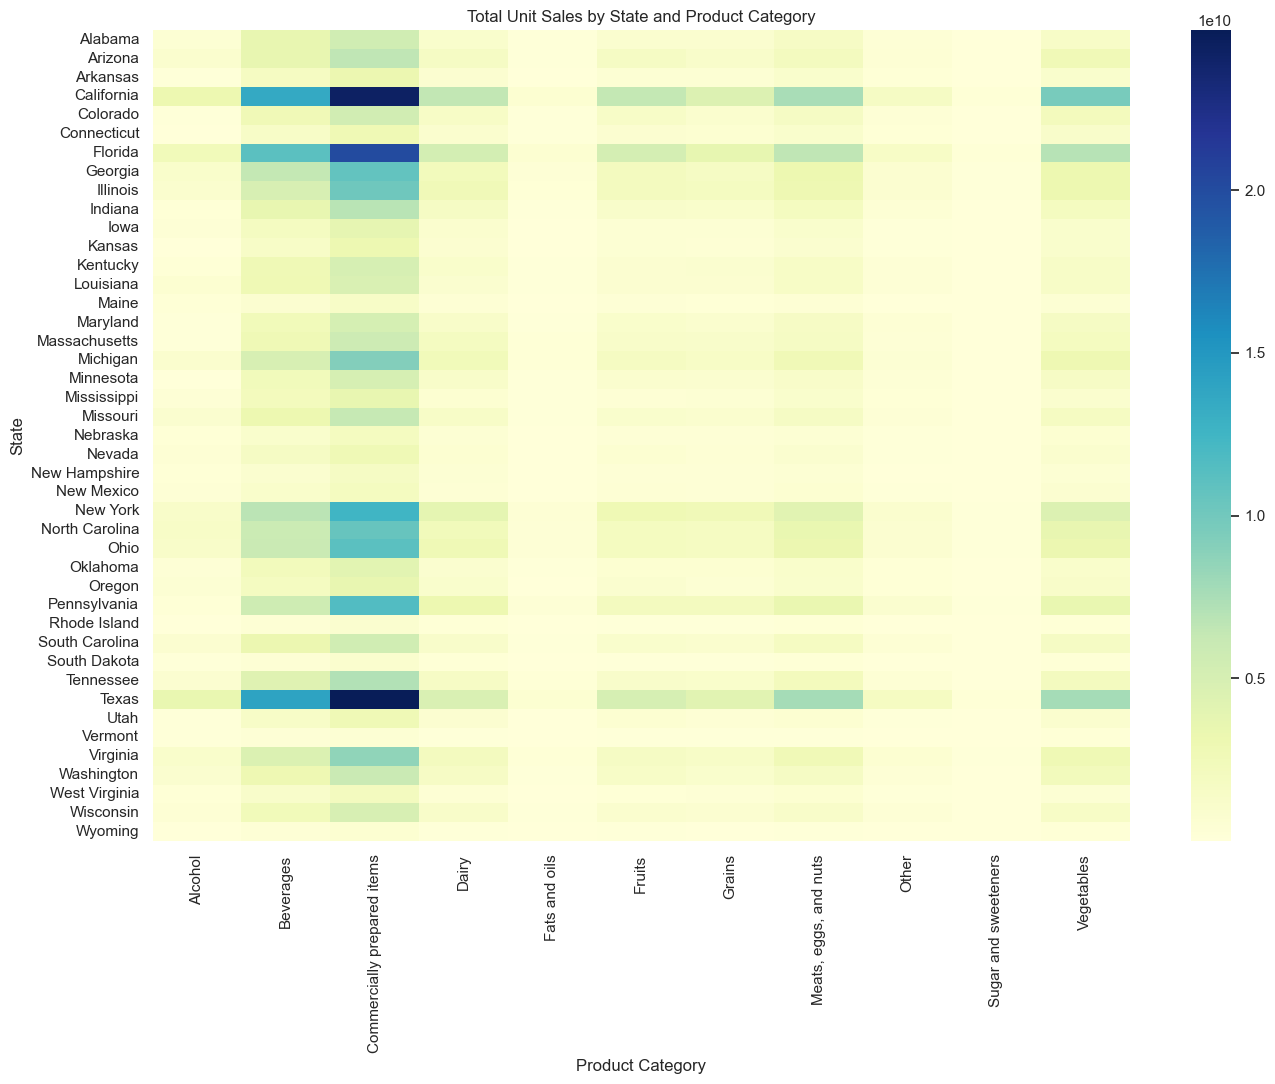

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# creating a heatmap for state and category demand
state_category_sales = unit_df.pivot_table(
    index="State",
    columns="Category",
    values="unit_sales",
    aggfunc="sum"
)

plt.figure(figsize=(14, 11))
sns.heatmap(state_category_sales, cmap="YlGnBu")
plt.title("Total Unit Sales by State and Product Category")
plt.xlabel("Product Category")
plt.ylabel("State")
plt.tight_layout()
plt.show()

## Feature Engineering

In [ ]:
import numpy as np
import pandas as pd

# creating one week ahead forecasting features
model_df = unit_df.sort_values(["State", "Category", "Date"]).reset_index(drop=True).copy()

# creating calendar features known before the target week ends
model_df["year"] = model_df["Date"].dt.year
model_df["month"] = model_df["Date"].dt.month
model_df["quarter"] = model_df["Date"].dt.quarter
model_df["week_of_year"] = model_df["Date"].dt.isocalendar().week.astype(int)
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)
model_df["week_sin"] = np.sin(2 * np.pi * model_df["week_of_year"] / 52)
model_df["week_cos"] = np.cos(2 * np.pi * model_df["week_of_year"] / 52)

# creating lagged features from past unit sales only
group_cols = ["State", "Category"]
for lag in [1, 2, 4, 8, 12, 13, 26, 52]:
    model_df[f"lag_{lag}"] = model_df.groupby(group_cols)["unit_sales"].shift(lag)

# creating rolling features after shifting by one week
for window in [4, 8, 12, 13, 26]:
    shifted_sales = model_df.groupby(group_cols)["unit_sales"].shift(1)
    model_df[f"rolling_mean_{window}"] = shifted_sales.groupby([model_df["State"], model_df["Category"]]).transform(
        lambda x: x.rolling(window, min_periods=2).mean()
    )
    model_df[f"rolling_std_{window}"] = shifted_sales.groupby([model_df["State"], model_df["Category"]]).transform(
        lambda x: x.rolling(window, min_periods=3).std()
    )

print("Feature rows created:", len(model_df))
model_df.head()

Feature rows created: 88924


,Date,State,Category,unit_sales,year,month,quarter,week_of_year,month_sin,month_cos,...,rolling_mean_4,rolling_std_4,rolling_mean_8,rolling_std_8,rolling_mean_12,rolling_std_12,rolling_mean_13,rolling_std_13,rolling_mean_26,rolling_std_26
0,2019-10-06,Alabama,Alcohol,2974221.0,2019,10,4,40,-0.866025,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-10-13,Alabama,Alcohol,2895573.0,2019,10,4,41,-0.866025,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-10-20,Alabama,Alcohol,2730939.0,2019,10,4,42,-0.866025,0.500000,...,2934897.00,NaN,2934897.00,NaN,2934897.00,NaN,2934897.00,NaN,2934897.00,NaN
3,2019-10-27,Alabama,Alcohol,2764970.0,2019,10,4,43,-0.866025,0.500000,...,2866911.00,124147.756983,2866911.00,124147.756983,2866911.00,124147.756983,2866911.00,124147.756983,2866911.00,124147.756983
4,2019-11-03,Alabama,Alcohol,2872683.0,2019,11,4,44,-0.500000,0.866025,...,2841425.75,113459.694369,2841425.75,113459.694369,2841425.75,113459.694369,2841425.75,113459.694369,2841425.75,113459.694369


In [ ]:
import pandas as pd

# checking that no current week sales value is used as a feature
feature_check = pd.DataFrame({
    "Rule": [
        "Current-week Dollars used",
        "Current-week Unit sales used as a feature",
        "Lag features use shift",
        "Rolling features use shift before rolling",
        "Actual missing targets kept as missing"
    ],
    "Status": [
        "No",
        "No",
        "Yes",
        "Yes",
        "Yes"
    ]
})

display(feature_check)

,Rule,Status
0,Current-week Dollars used,No
1,Current-week Unit sales used as a feature,No
2,Lag features use shift,Yes
3,Rolling features use shift before rolling,Yes
4,Actual missing targets kept as missing,Yes


## Chronological Split

In [15]:
import pandas as pd

# splitting the data by date only
train_end = pd.Timestamp("2021-12-31")
validation_end = pd.Timestamp("2022-06-30")
test_start = pd.Timestamp("2022-07-01")

train_df = model_df[model_df["Date"] <= train_end].copy()
validation_df = model_df[(model_df["Date"] > train_end) & (model_df["Date"] <= validation_end)].copy()
test_df = model_df[model_df["Date"] >= test_start].copy()

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Date range": [
        f"{train_df['Date'].min().date()} to {train_df['Date'].max().date()}",
        f"{validation_df['Date'].min().date()} to {validation_df['Date'].max().date()}",
        f"{test_df['Date'].min().date()} to {test_df['Date'].max().date()}"
    ],
    "Rows": [len(train_df), len(validation_df), len(test_df)],
    "Missing actual targets": [
        train_df["unit_sales"].isna().sum(),
        validation_df["unit_sales"].isna().sum(),
        test_df["unit_sales"].isna().sum()
    ]
})

display(split_summary)

,Split,Date range,Rows,Missing actual targets
0,Train,2019-10-06 to 2021-12-26,55341,0
1,Validation,2022-01-02 to 2022-06-26,12298,1
2,Test,2022-07-03 to 2023-05-07,21285,12


## Model Data

In [16]:
import pandas as pd
from sklearn.impute import SimpleImputer

# preparing model inputs
numeric_features = [
    "year",
    "month",
    "quarter",
    "week_of_year",
    "month_sin",
    "month_cos",
    "week_sin",
    "week_cos",
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "lag_12",
    "lag_13",
    "lag_26",
    "lag_52",
    "rolling_mean_4",
    "rolling_std_4",
    "rolling_mean_8",
    "rolling_std_8",
    "rolling_mean_12",
    "rolling_std_12",
    "rolling_mean_13",
    "rolling_std_13",
    "rolling_mean_26",
    "rolling_std_26"
]

feature_columns = ["State", "Category"] + numeric_features

# using train and validation history for final model fitting
train_validation_df = pd.concat([train_df, validation_df], ignore_index=True)
train_validation_fit_df = train_validation_df.dropna(subset=["unit_sales"]).copy()

X_fit_raw = pd.get_dummies(train_validation_fit_df[feature_columns], columns=["State", "Category"])
X_test_raw = pd.get_dummies(test_df[feature_columns], columns=["State", "Category"])
X_fit_raw, X_test_raw = X_fit_raw.align(X_test_raw, join="left", axis=1, fill_value=0)

imputer = SimpleImputer(strategy="median")
X_fit = pd.DataFrame(imputer.fit_transform(X_fit_raw), columns=X_fit_raw.columns, index=X_fit_raw.index)
X_test = pd.DataFrame(imputer.transform(X_test_raw), columns=X_test_raw.columns, index=X_test_raw.index)

y_fit = train_validation_fit_df["unit_sales"].values

test_actual_df = test_df[["Date", "State", "Category", "unit_sales"]].copy()
test_actual_df = test_actual_df.rename(columns={"unit_sales": "Actual"})

print("Training rows used for final model fitting:", len(X_fit))
print("Test rows before excluding missing actuals:", len(test_actual_df))
print("Missing actual targets in test:", test_actual_df["Actual"].isna().sum())

Training rows used for final model fitting: 67638
Test rows before excluding missing actuals: 21285
Missing actual targets in test: 12


## Metric Functions

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# storing predictions and metrics
model_prediction_tables = {}

def calculate_metrics(actual, predicted):
    forecast_error = predicted - actual
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    wape = np.sum(np.abs(forecast_error)) / np.sum(actual)
    forecast_bias = np.sum(forecast_error) / np.sum(actual)
    r2 = r2_score(actual, predicted)
    return mae, mse, rmse, wape, forecast_bias, r2

def make_prediction_table(model_name, base_df, predictions):
    prediction_table = base_df[["Date", "State", "Category", "Actual"]].copy()
    prediction_table[model_name] = predictions
    model_prediction_tables[model_name] = prediction_table

def display_single_model_metrics(model_name, actual, predicted):
    mae, mse, rmse, wape, forecast_bias, r2 = calculate_metrics(actual, predicted)
    metrics_table = pd.DataFrame([{
        "Model": model_name,
        "Evaluation rows": len(actual),
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "WAPE": wape,
        "Forecast Bias": forecast_bias,
        "R-squared": r2
    }])
    display(metrics_table.round(4))

## Exponential Smoothing Model

In [18]:
import numpy as np
import pandas as pd
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

# training exponential smoothing separately for each state and category
warnings.filterwarnings("ignore")
stat_predictions = []

for (state, category), group in model_df.groupby(["State", "Category"]):
    group = group.sort_values("Date")
    history = group[group["Date"] < test_start][["Date", "unit_sales"]].copy()
    future = group[group["Date"] >= test_start][["Date", "State", "Category", "unit_sales"]].copy()
    
    history_values = history["unit_sales"].ffill()
    history_values = history_values.bfill()
    history_array = history_values.to_numpy(dtype=float)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            smoothing_model = ExponentialSmoothing(
                history_array,
                trend="add",
                seasonal=None,
                initialization_method="estimated"
            ).fit(optimized=True)
        except Exception:
            smoothing_model = SimpleExpSmoothing(
                history_array,
                initialization_method="estimated"
            ).fit(optimized=True)
    
    forecast_values = smoothing_model.forecast(len(future))
    future["Exponential Smoothing"] = np.maximum(np.asarray(forecast_values), 0)
    stat_predictions.append(future[["Date", "State", "Category", "unit_sales", "Exponential Smoothing"]])

stat_prediction_df = pd.concat(stat_predictions, ignore_index=True)
stat_prediction_df = stat_prediction_df.rename(columns={"unit_sales": "Actual"})

make_prediction_table(
    "Exponential Smoothing",
    stat_prediction_df[["Date", "State", "Category", "Actual"]],
    stat_prediction_df["Exponential Smoothing"].values
)

stat_eval_df = stat_prediction_df.dropna(subset=["Actual"])
display_single_model_metrics(
    "Exponential Smoothing",
    stat_eval_df["Actual"].values,
    stat_eval_df["Exponential Smoothing"].values
)

,Model,Evaluation rows,MAE,MSE,RMSE,WAPE,Forecast Bias,R-squared
0,Exponential Smoothing,21273,876084.0026,4.503800e+12,2.122216e+06,0.0971,0.0233,0.979


## Random Forest Model

In [19]:
from sklearn.ensemble import RandomForestRegressor

# training the random forest regression model
rf_model = RandomForestRegressor(
    n_estimators=90,
    max_depth=16,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_fit, y_fit)
rf_predictions = np.maximum(rf_model.predict(X_test), 0)

make_prediction_table("Random Forest", test_actual_df, rf_predictions)

rf_eval_df = model_prediction_tables["Random Forest"].dropna(subset=["Actual"])
display_single_model_metrics(
    "Random Forest",
    rf_eval_df["Actual"].values,
    rf_eval_df["Random Forest"].values
)

,Model,Evaluation rows,MAE,MSE,RMSE,WAPE,Forecast Bias,R-squared
0,Random Forest,21273,343941.117,7.568372e+11,869963.9309,0.0381,0.0091,0.9965


## XGBoost Model

In [20]:
from xgboost import XGBRegressor

# training the xgboost regression model
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=260,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    n_jobs=4,
    tree_method="hist"
)

xgb_model.fit(X_fit, y_fit)
xgb_predictions = np.maximum(xgb_model.predict(X_test), 0)

make_prediction_table("XGBoost", test_actual_df, xgb_predictions)

xgb_eval_df = model_prediction_tables["XGBoost"].dropna(subset=["Actual"])
display_single_model_metrics(
    "XGBoost",
    xgb_eval_df["Actual"].values,
    xgb_eval_df["XGBoost"].values
)

,Model,Evaluation rows,MAE,MSE,RMSE,WAPE,Forecast Bias,R-squared
0,XGBoost,21273,361444.2862,8.570623e+11,925776.5943,0.04,-0.0009,0.996


## SVR Model

In [21]:
import numpy as np
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# training svr on a sample and evaluating on the full test set
rng = np.random.default_rng(42)
svr_train_size = min(7000, len(X_fit))
svr_train_index = rng.choice(len(X_fit), size=svr_train_size, replace=False)

svr_model = make_pipeline(
    StandardScaler(),
    TransformedTargetRegressor(
        regressor=SVR(kernel="rbf", C=10, epsilon=0.1),
        func=np.log1p,
        inverse_func=np.expm1
    )
)

svr_model.fit(X_fit.iloc[svr_train_index], y_fit[svr_train_index])
svr_predictions = np.maximum(svr_model.predict(X_test), 0)

make_prediction_table("SVR", test_actual_df, svr_predictions)

svr_eval_df = model_prediction_tables["SVR"].dropna(subset=["Actual"])
display_single_model_metrics(
    "SVR",
    svr_eval_df["Actual"].values,
    svr_eval_df["SVR"].values
)

,Model,Evaluation rows,MAE,MSE,RMSE,WAPE,Forecast Bias,R-squared
0,SVR,21273,745918.6027,7.492299e+12,2.737206e+06,0.0826,0.0033,0.965


## Deep Learning Data

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# preparing sequence data for one week ahead deep learning models
sequence_df = unit_df.sort_values(["State", "Category", "Date"]).reset_index(drop=True).copy()
sequence_df["sales_input"] = sequence_df.groupby(["State", "Category"])["unit_sales"].ffill()
sequence_df["sales_input"] = sequence_df.groupby(["State", "Category"])["sales_input"].bfill()
sequence_df["log_sales_input"] = np.log1p(sequence_df["sales_input"])
sequence_df["log_sales_target"] = np.log1p(sequence_df["unit_sales"])

sequence_df["month"] = sequence_df["Date"].dt.month
sequence_df["week_of_year"] = sequence_df["Date"].dt.isocalendar().week.astype(int)
sequence_df["month_sin"] = np.sin(2 * np.pi * sequence_df["month"] / 12)
sequence_df["month_cos"] = np.cos(2 * np.pi * sequence_df["month"] / 12)
sequence_df["week_sin"] = np.sin(2 * np.pi * sequence_df["week_of_year"] / 52)
sequence_df["week_cos"] = np.cos(2 * np.pi * sequence_df["week_of_year"] / 52)
sequence_df["state_code"] = pd.Categorical(sequence_df["State"]).codes
sequence_df["category_code"] = pd.Categorical(sequence_df["Category"]).codes
sequence_df["state_scaled"] = sequence_df["state_code"] / max(sequence_df["state_code"].max(), 1)
sequence_df["category_scaled"] = sequence_df["category_code"] / max(sequence_df["category_code"].max(), 1)

sequence_features = [
    "log_sales_input",
    "month_sin",
    "month_cos",
    "week_sin",
    "week_cos",
    "state_scaled",
    "category_scaled"
]

lookback = 12
sequence_rows = []
X_sequences = []
y_sequences = []

for _, group in sequence_df.groupby(["State", "Category"]):
    group = group.sort_values("Date").reset_index(drop=True)
    values = group[sequence_features].values
    for row in range(lookback, len(group)):
        sequence_rows.append(group.loc[row, ["Date", "State", "Category", "unit_sales"]].to_dict())
        X_sequences.append(values[row - lookback:row])
        y_sequences.append(group.loc[row, "log_sales_target"])

sequence_meta_df = pd.DataFrame(sequence_rows)
X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

train_seq_mask = sequence_meta_df["Date"] <= train_end
validation_seq_mask = (sequence_meta_df["Date"] > train_end) & (sequence_meta_df["Date"] <= validation_end)
test_seq_mask = sequence_meta_df["Date"] >= test_start

# training does not use rows where the target is missing
train_seq_mask = train_seq_mask & sequence_meta_df["unit_sales"].notna()
validation_seq_mask = validation_seq_mask & sequence_meta_df["unit_sales"].notna()

X_seq_train = X_sequences[train_seq_mask]
y_seq_train = y_sequences[train_seq_mask]
X_seq_validation = X_sequences[validation_seq_mask]
y_seq_validation = y_sequences[validation_seq_mask]
X_seq_test = X_sequences[test_seq_mask]
test_sequence_meta = sequence_meta_df[test_seq_mask].reset_index(drop=True)

sequence_scaler = StandardScaler()
sequence_scaler.fit(X_seq_train.reshape(-1, X_seq_train.shape[-1]))

def scale_sequences(values):
    original_shape = values.shape
    scaled_values = sequence_scaler.transform(values.reshape(-1, original_shape[-1]))
    return scaled_values.reshape(original_shape)

X_seq_train = scale_sequences(X_seq_train)
X_seq_validation = scale_sequences(X_seq_validation)
X_seq_test = scale_sequences(X_seq_test)

sequence_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Sequences": [len(X_seq_train), len(X_seq_validation), len(X_seq_test)]
})

display(sequence_summary)

,Split,Sequences
0,Train,49665
1,Validation,12297
2,Test,21285


## LSTM Model

In [23]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import random
import warnings
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# training the lstm model
warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

lstm_model = Sequential([
    Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    LSTM(32),
    Dropout(0.15),
    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

lstm_history = lstm_model.fit(
    X_seq_train,
    y_seq_train,
    validation_data=(X_seq_validation, y_seq_validation),
    epochs=10,
    batch_size=256,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=0
)

lstm_predictions = np.maximum(np.expm1(lstm_model.predict(X_seq_test, verbose=0).ravel()), 0)
lstm_prediction_df = test_sequence_meta[["Date", "State", "Category", "unit_sales"]].copy()
lstm_prediction_df = lstm_prediction_df.rename(columns={"unit_sales": "Actual"})
lstm_prediction_df["LSTM"] = lstm_predictions

make_prediction_table(
    "LSTM",
    lstm_prediction_df[["Date", "State", "Category", "Actual"]],
    lstm_prediction_df["LSTM"].values
)

lstm_eval_df = lstm_prediction_df.dropna(subset=["Actual"])
display_single_model_metrics(
    "LSTM",
    lstm_eval_df["Actual"].values,
    lstm_eval_df["LSTM"].values
)

,Model,Evaluation rows,MAE,MSE,RMSE,WAPE,Forecast Bias,R-squared
0,LSTM,21273,2.101484e+06,6.222839e+13,7888497.433,0.2328,-0.1767,0.7093


## GRU Model

In [24]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import random
import warnings
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, GRU, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# training the gru model
warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

gru_model = Sequential([
    Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    GRU(32),
    Dropout(0.15),
    Dense(16, activation="relu"),
    Dense(1)
])

gru_model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

gru_history = gru_model.fit(
    X_seq_train,
    y_seq_train,
    validation_data=(X_seq_validation, y_seq_validation),
    epochs=10,
    batch_size=256,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=0
)

gru_predictions = np.maximum(np.expm1(gru_model.predict(X_seq_test, verbose=0).ravel()), 0)
gru_prediction_df = test_sequence_meta[["Date", "State", "Category", "unit_sales"]].copy()
gru_prediction_df = gru_prediction_df.rename(columns={"unit_sales": "Actual"})
gru_prediction_df["GRU"] = gru_predictions

make_prediction_table(
    "GRU",
    gru_prediction_df[["Date", "State", "Category", "Actual"]],
    gru_prediction_df["GRU"].values
)

gru_eval_df = gru_prediction_df.dropna(subset=["Actual"])
display_single_model_metrics(
    "GRU",
    gru_eval_df["Actual"].values,
    gru_eval_df["GRU"].values
)

,Model,Evaluation rows,MAE,MSE,RMSE,WAPE,Forecast Bias,R-squared
0,GRU,21273,4460303.249,1.402615e+14,1.184320e+07,0.4942,-0.4454,0.3447


## Deep Learning Training Plots

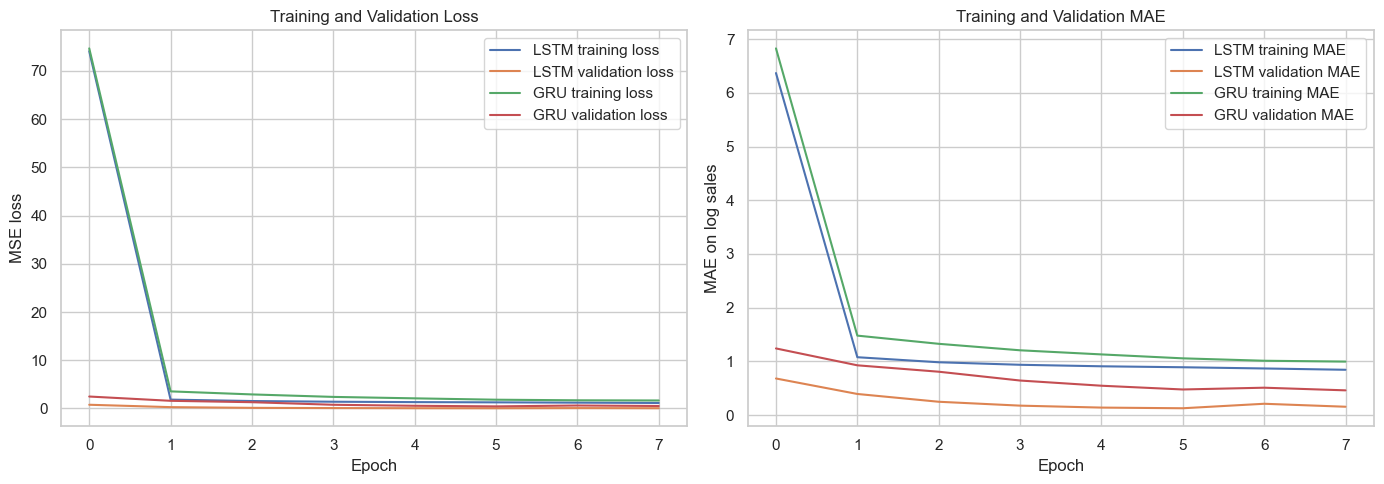

In [25]:
import matplotlib.pyplot as plt

# plotting training and validation performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_history.history["loss"], label="LSTM training loss")
axes[0].plot(lstm_history.history["val_loss"], label="LSTM validation loss")
axes[0].plot(gru_history.history["loss"], label="GRU training loss")
axes[0].plot(gru_history.history["val_loss"], label="GRU validation loss")
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")
axes[0].legend()

axes[1].plot(lstm_history.history["mae"], label="LSTM training MAE")
axes[1].plot(lstm_history.history["val_mae"], label="LSTM validation MAE")
axes[1].plot(gru_history.history["mae"], label="GRU training MAE")
axes[1].plot(gru_history.history["val_mae"], label="GRU validation MAE")
axes[1].set_title("Training and Validation MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE on log sales")
axes[1].legend()

plt.tight_layout()
plt.show()

## Common Test Set

In [26]:
import pandas as pd

# combining predictions so every model is evaluated on the same rows
common_test_df = test_actual_df[["Date", "State", "Category", "Actual"]].copy()

for model_name, prediction_table in model_prediction_tables.items():
    model_values = prediction_table[["Date", "State", "Category", model_name]]
    common_test_df = common_test_df.merge(model_values, on=["Date", "State", "Category"], how="left")

model_names = list(model_prediction_tables.keys())
common_test_df = common_test_df.dropna(subset=["Actual"] + model_names).reset_index(drop=True)

print("Common test observations used for every final metric:", len(common_test_df))
display(common_test_df.head())

Common test observations used for every final metric: 21273


,Date,State,Category,Actual,Exponential Smoothing,Random Forest,XGBoost,SVR,LSTM,GRU
0,2022-07-03,Alabama,Alcohol,3283438.0,3.040079e+06,3.106163e+06,3128553.75,3.016082e+06,2595838.75,4375579.00
1,2022-07-10,Alabama,Alcohol,3034812.0,3.032790e+06,3.057821e+06,3254667.00,3.013810e+06,2667118.75,3879207.25
2,2022-07-17,Alabama,Alcohol,2981848.0,3.025500e+06,3.057086e+06,2976966.75,2.987309e+06,2704930.00,3945891.50
3,2022-07-24,Alabama,Alcohol,2883954.0,3.018211e+06,3.022841e+06,2969917.00,2.962104e+06,2756833.50,4290768.00
4,2022-07-31,Alabama,Alcohol,3036129.0,3.010922e+06,3.011463e+06,2922544.75,2.939925e+06,2783163.00,4608707.50


## Final Model Comparison

In [27]:
import pandas as pd

# calculating final metrics on the same test observations
comparison_rows = []

for model_name in model_names:
    actual_values = common_test_df["Actual"].values
    predicted_values = common_test_df[model_name].values
    mae, mse, rmse, wape, forecast_bias, r2 = calculate_metrics(actual_values, predicted_values)
    comparison_rows.append({
        "Model": model_name,
        "Evaluation rows": len(common_test_df),
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "WAPE": wape,
        "Forecast Bias": forecast_bias,
        "R-squared": r2
    })

model_comparison = pd.DataFrame(comparison_rows)
model_comparison = model_comparison.sort_values(["RMSE", "MAE", "WAPE"]).reset_index(drop=True)
display(model_comparison.round(4))

,Model,Evaluation rows,MAE,MSE,RMSE,WAPE,Forecast Bias,R-squared
0,Random Forest,21273,3.439411e+05,7.568372e+11,8.699639e+05,0.0381,0.0091,0.9965
1,XGBoost,21273,3.614443e+05,8.570623e+11,9.257766e+05,0.0400,-0.0009,0.9960
2,Exponential Smoothing,21273,8.760840e+05,4.503800e+12,2.122216e+06,0.0971,0.0233,0.9790
3,SVR,21273,7.459186e+05,7.492299e+12,2.737206e+06,0.0826,0.0033,0.9650
4,LSTM,21273,2.101484e+06,6.222839e+13,7.888497e+06,0.2328,-0.1767,0.7093
5,GRU,21273,4.460303e+06,1.402615e+14,1.184320e+07,0.4942,-0.4454,0.3447


In [28]:
import pandas as pd

# selecting the best model using error metrics, bias and interpretability
selection_table = model_comparison.copy()

selection_table["RMSE Rank"] = selection_table["RMSE"].rank(method="min")
selection_table["MAE Rank"] = selection_table["MAE"].rank(method="min")
selection_table["WAPE Rank"] = selection_table["WAPE"].rank(method="min")
selection_table["Bias Rank"] = selection_table["Forecast Bias"].abs().rank(method="min")

interpretability_scores = {
    "XGBoost": 1,
    "Random Forest": 1,
    "Exponential Smoothing": 2,
    "SVR": 3,
    "LSTM": 4,
    "GRU": 4
}

selection_table["Interpretability Rank"] = selection_table["Model"].map(interpretability_scores)
selection_table["Overall Selection Score"] = (
    selection_table["RMSE Rank"]
    + selection_table["MAE Rank"]
    + selection_table["WAPE Rank"]
    + selection_table["Bias Rank"]
    + selection_table["Interpretability Rank"]
)

selection_table = selection_table.sort_values("Overall Selection Score").reset_index(drop=True)
selected_model_name = selection_table.loc[0, "Model"]

display(selection_table[[
    "Model",
    "RMSE Rank",
    "MAE Rank",
    "WAPE Rank",
    "Bias Rank",
    "Interpretability Rank",
    "Overall Selection Score"
]].round(2))

print("Selected best model:", selected_model_name)

,Model,RMSE Rank,MAE Rank,WAPE Rank,Bias Rank,Interpretability Rank,Overall Selection Score
0,Random Forest,1.0,1.0,1.0,3.0,1,7.0
1,XGBoost,2.0,2.0,2.0,1.0,1,8.0
2,SVR,4.0,3.0,3.0,2.0,3,15.0
3,Exponential Smoothing,3.0,4.0,4.0,4.0,2,17.0
4,LSTM,5.0,5.0,5.0,5.0,4,24.0
5,GRU,6.0,6.0,6.0,6.0,4,28.0


Selected best model: Random Forest


## Model Comparison Plots

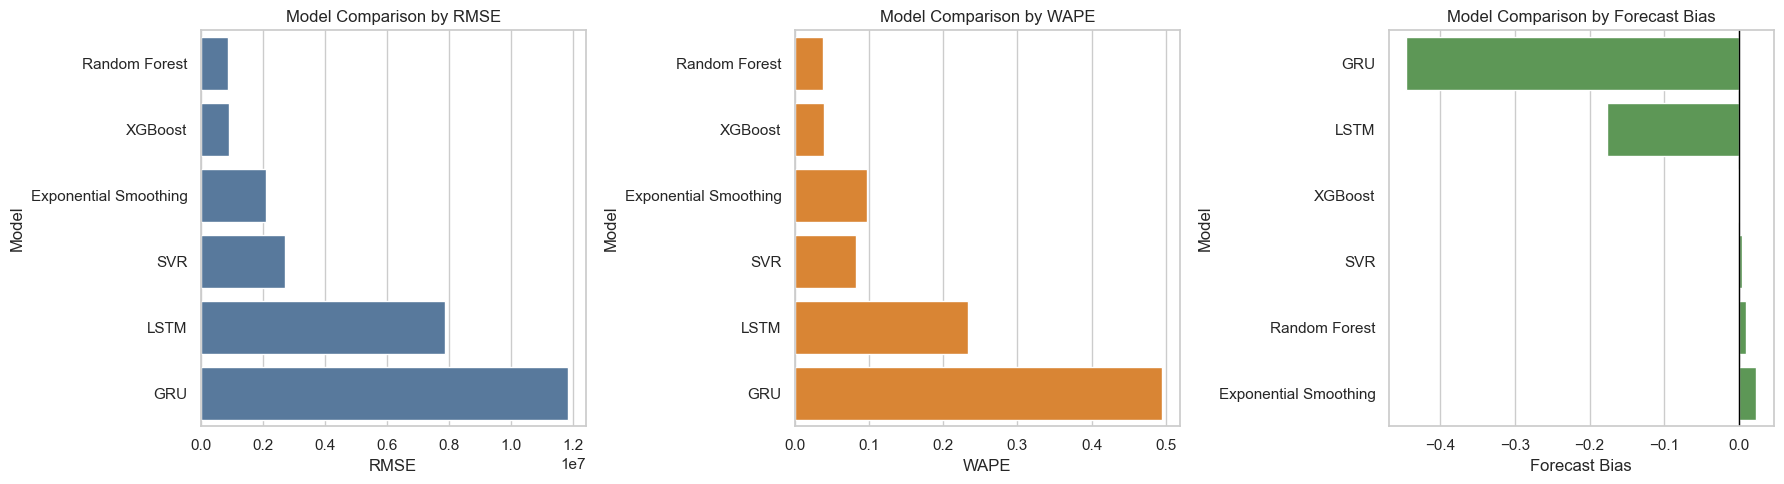

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# plotting model comparison results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=model_comparison, y="Model", x="RMSE", ax=axes[0], color="#4C78A8")
axes[0].set_title("Model Comparison by RMSE")
axes[0].set_xlabel("RMSE")
axes[0].set_ylabel("Model")

sns.barplot(data=model_comparison, y="Model", x="WAPE", ax=axes[1], color="#F58518")
axes[1].set_title("Model Comparison by WAPE")
axes[1].set_xlabel("WAPE")
axes[1].set_ylabel("Model")

bias_order = model_comparison.sort_values("Forecast Bias")
sns.barplot(data=bias_order, y="Model", x="Forecast Bias", ax=axes[2], color="#54A24B")
axes[2].axvline(0, color="black", linewidth=1)
axes[2].set_title("Model Comparison by Forecast Bias")
axes[2].set_xlabel("Forecast Bias")
axes[2].set_ylabel("Model")

plt.tight_layout()
plt.show()

## Actual Versus Predicted Values

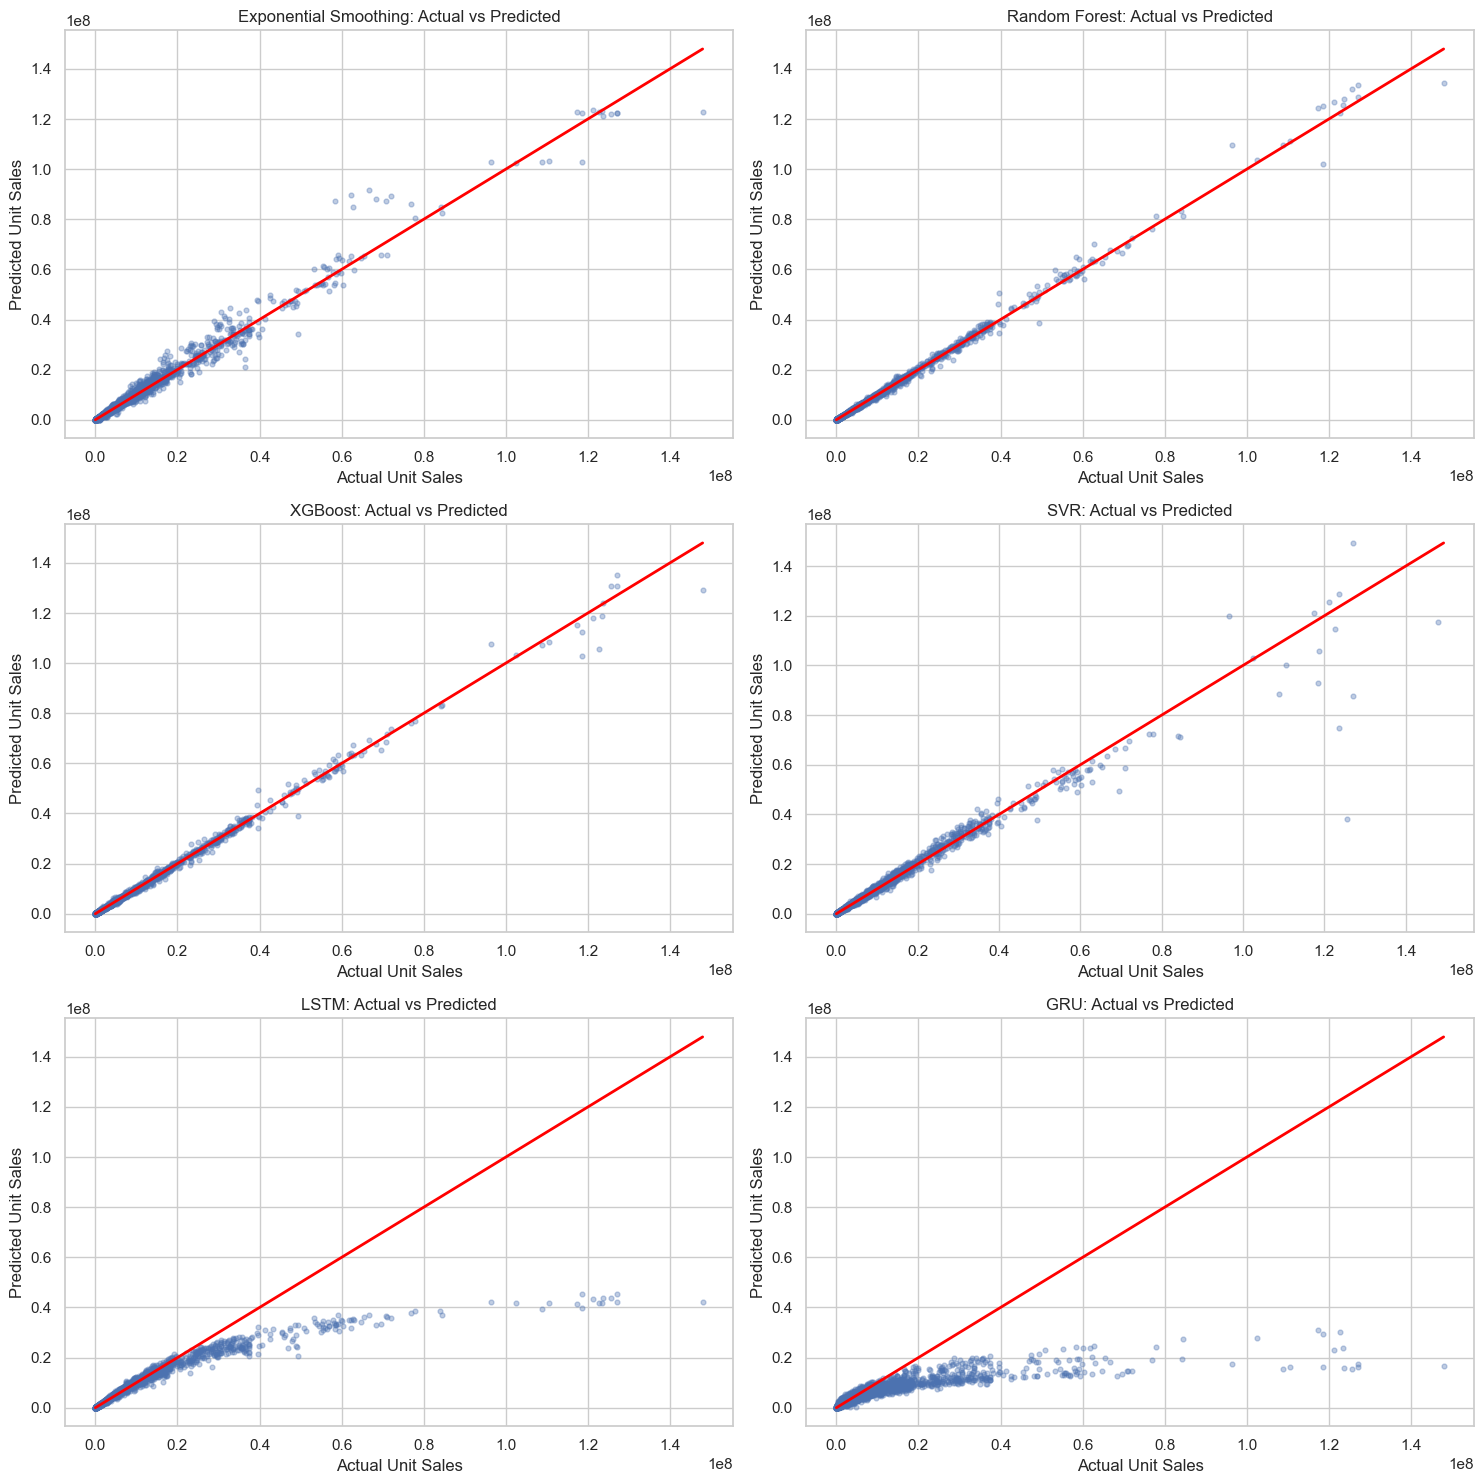

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# plotting actual versus predicted values for every model
cols = 2
rows = int(np.ceil(len(model_names) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = np.array(axes).reshape(-1)

for ax, model_name in zip(axes, model_names):
    actual_values = common_test_df["Actual"].values
    predicted_values = common_test_df[model_name].values
    sample_size = min(2500, len(common_test_df))
    sample_index = np.linspace(0, len(common_test_df) - 1, sample_size).astype(int)
    ax.scatter(actual_values[sample_index], predicted_values[sample_index], alpha=0.35, s=12)
    min_value = min(actual_values[sample_index].min(), predicted_values[sample_index].min())
    max_value = max(actual_values[sample_index].max(), predicted_values[sample_index].max())
    ax.plot([min_value, max_value], [min_value, max_value], color="red", linewidth=2)
    ax.set_title(f"{model_name}: Actual vs Predicted")
    ax.set_xlabel("Actual Unit Sales")
    ax.set_ylabel("Predicted Unit Sales")

for ax in axes[len(model_names):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Forecast Error Plots

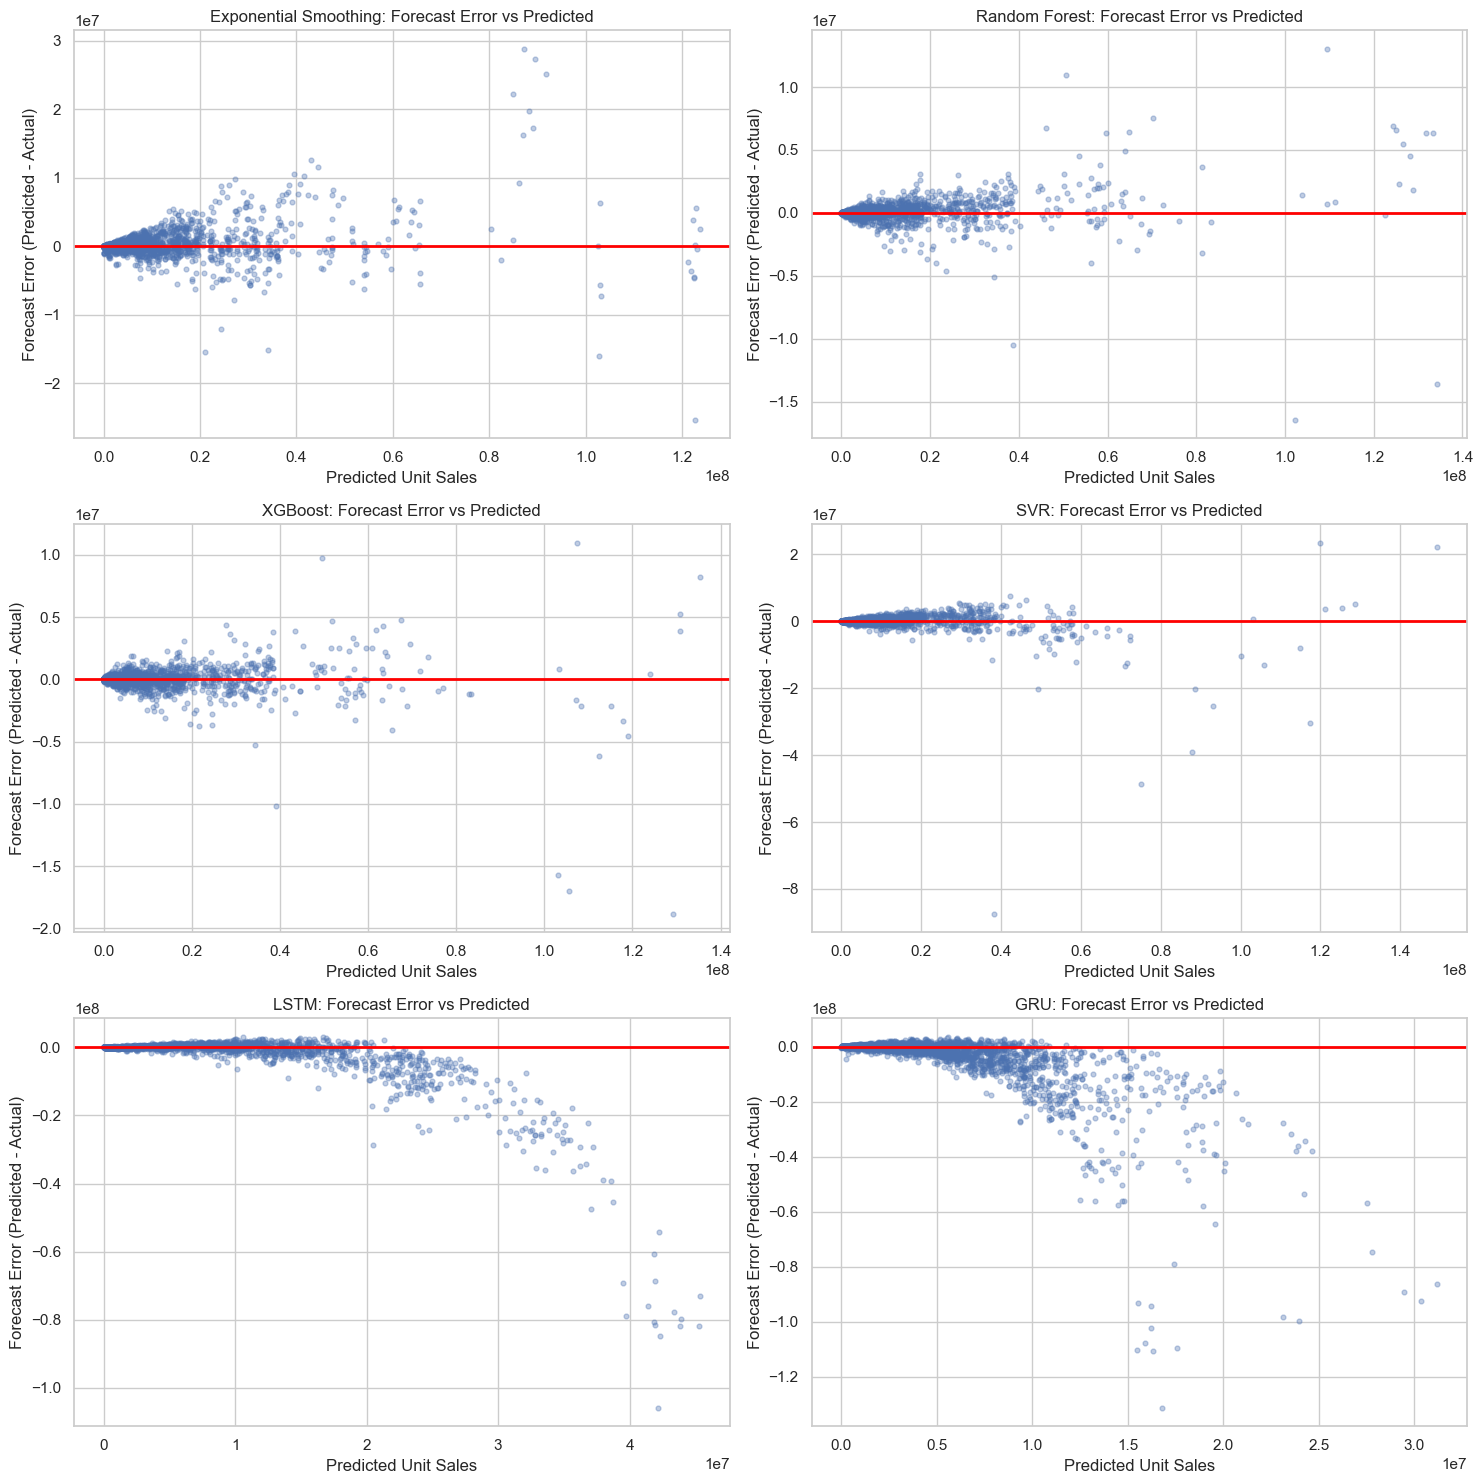

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# plotting forecast error against predicted values
cols = 2
rows = int(np.ceil(len(model_names) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = np.array(axes).reshape(-1)

for ax, model_name in zip(axes, model_names):
    predicted_values = common_test_df[model_name].values
    forecast_error = predicted_values - common_test_df["Actual"].values
    sample_size = min(2500, len(common_test_df))
    sample_index = np.linspace(0, len(common_test_df) - 1, sample_size).astype(int)
    ax.scatter(predicted_values[sample_index], forecast_error[sample_index], alpha=0.35, s=12)
    ax.axhline(0, color="red", linewidth=2)
    ax.set_title(f"{model_name}: Forecast Error vs Predicted")
    ax.set_xlabel("Predicted Unit Sales")
    ax.set_ylabel("Forecast Error (Predicted - Actual)")

for ax in axes[len(model_names):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Forecast Error Distribution

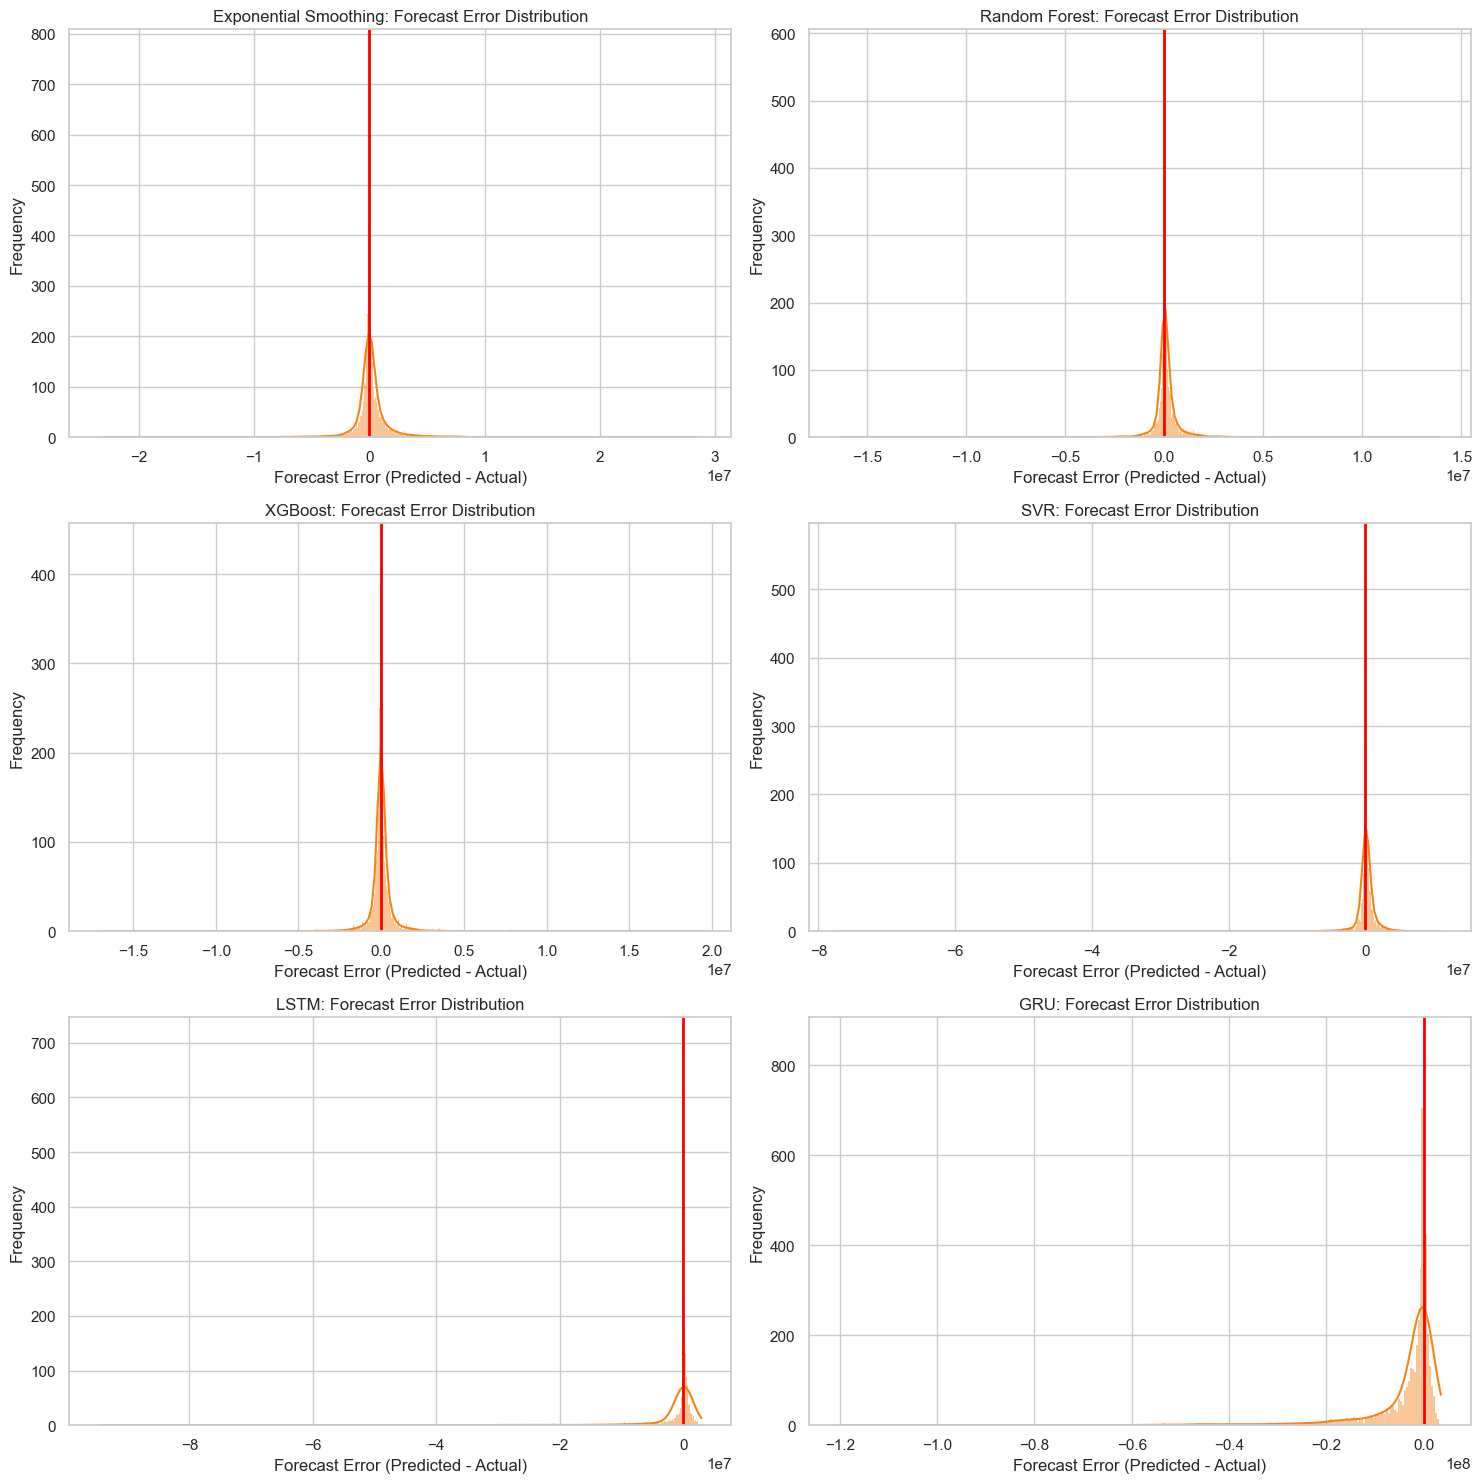

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# plotting forecast error distributions
cols = 2
rows = int(np.ceil(len(model_names) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = np.array(axes).reshape(-1)

for ax, model_name in zip(axes, model_names):
    forecast_error = common_test_df[model_name].values - common_test_df["Actual"].values
    sample_size = min(5000, len(common_test_df))
    sample_index = np.linspace(0, len(common_test_df) - 1, sample_size).astype(int)
    sns.histplot(forecast_error[sample_index], kde=True, ax=ax, color="#F58518")
    ax.axvline(0, color="red", linewidth=2)
    ax.set_title(f"{model_name}: Forecast Error Distribution")
    ax.set_xlabel("Forecast Error (Predicted - Actual)")
    ax.set_ylabel("Frequency")

for ax in axes[len(model_names):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Regression Diagnostic Plots

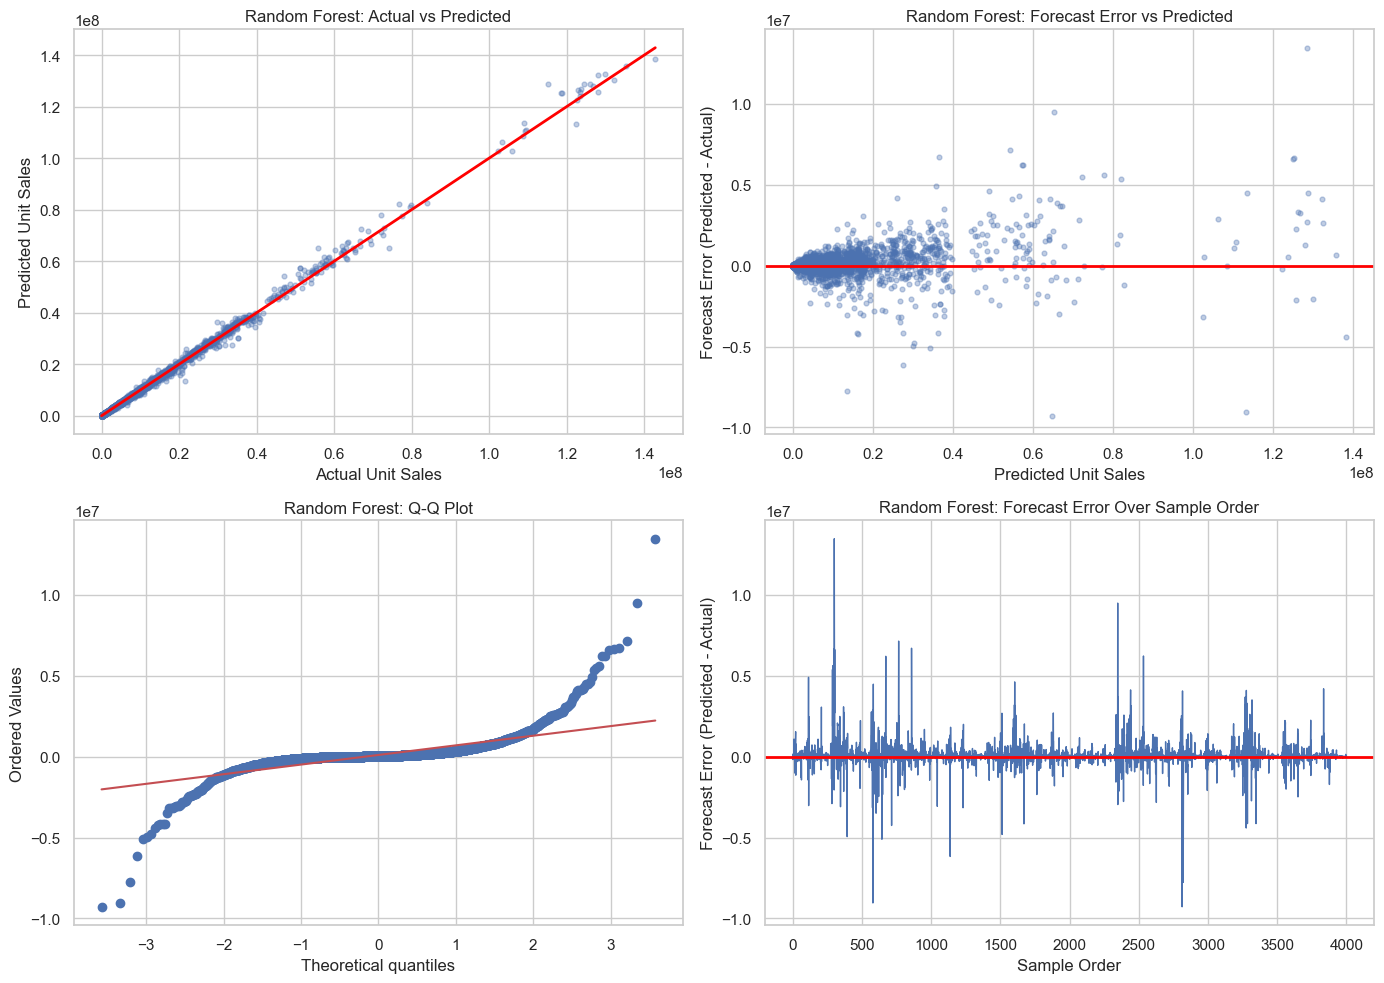

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# creating diagnostic plots for the selected model
selected_actual = common_test_df["Actual"].values
selected_predicted = common_test_df[selected_model_name].values
selected_error = selected_predicted - selected_actual

sample_size = min(4000, len(common_test_df))
sample_index = np.linspace(0, len(common_test_df) - 1, sample_size).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(selected_actual[sample_index], selected_predicted[sample_index], alpha=0.35, s=12)
min_value = min(selected_actual[sample_index].min(), selected_predicted[sample_index].min())
max_value = max(selected_actual[sample_index].max(), selected_predicted[sample_index].max())
axes[0, 0].plot([min_value, max_value], [min_value, max_value], color="red", linewidth=2)
axes[0, 0].set_title(f"{selected_model_name}: Actual vs Predicted")
axes[0, 0].set_xlabel("Actual Unit Sales")
axes[0, 0].set_ylabel("Predicted Unit Sales")

axes[0, 1].scatter(selected_predicted[sample_index], selected_error[sample_index], alpha=0.35, s=12)
axes[0, 1].axhline(0, color="red", linewidth=2)
axes[0, 1].set_title(f"{selected_model_name}: Forecast Error vs Predicted")
axes[0, 1].set_xlabel("Predicted Unit Sales")
axes[0, 1].set_ylabel("Forecast Error (Predicted - Actual)")

stats.probplot(selected_error[sample_index], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title(f"{selected_model_name}: Q-Q Plot")

axes[1, 1].plot(selected_error[sample_index], linewidth=1)
axes[1, 1].axhline(0, color="red", linewidth=2)
axes[1, 1].set_title(f"{selected_model_name}: Forecast Error Over Sample Order")
axes[1, 1].set_xlabel("Sample Order")
axes[1, 1].set_ylabel("Forecast Error (Predicted - Actual)")

plt.tight_layout()
plt.show()

## Feature Importance

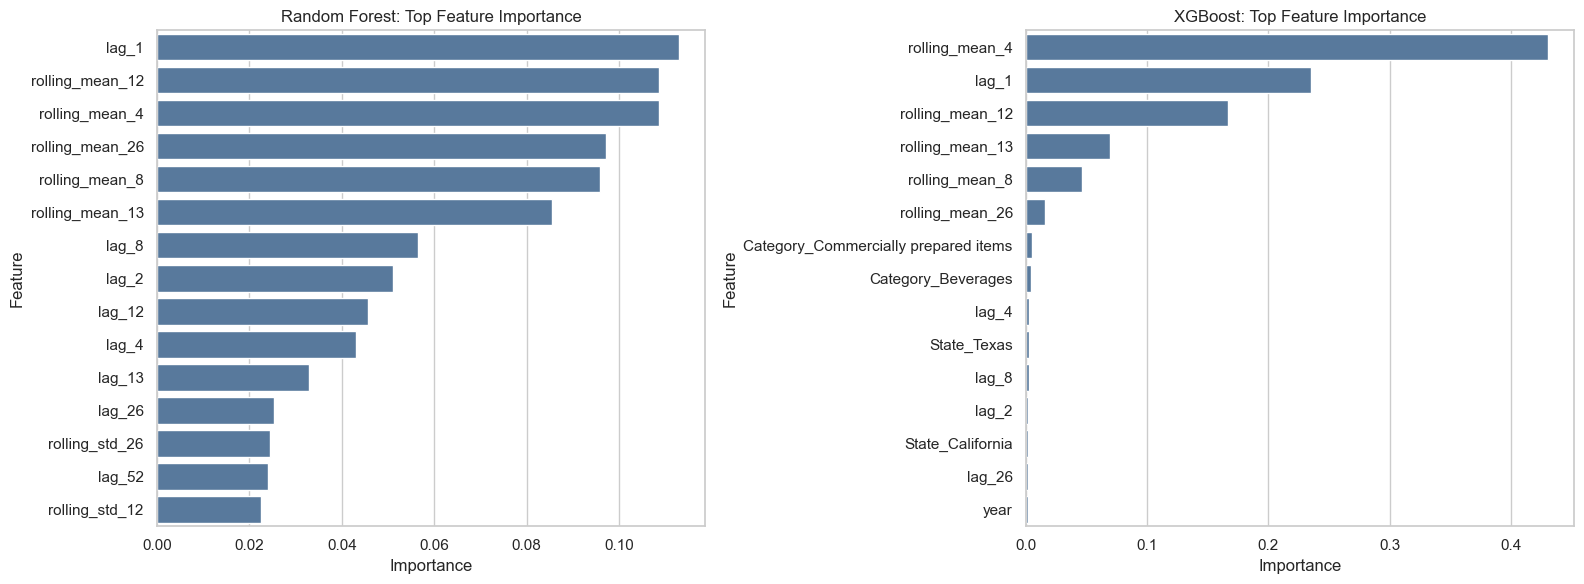

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# plotting feature importance for tree models
tree_importance_frames = []

tree_models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for model_name, model_object in tree_models.items():
    model_importance = pd.DataFrame({
        "Feature": X_fit.columns,
        "Importance": model_object.feature_importances_,
        "Model": model_name
    })
    tree_importance_frames.append(model_importance)

tree_importance_df = pd.concat(tree_importance_frames, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model_name in zip(axes, ["Random Forest", "XGBoost"]):
    top_features = (
        tree_importance_df[tree_importance_df["Model"] == model_name]
        .sort_values("Importance", ascending=False)
        .head(15)
    )
    sns.barplot(data=top_features, y="Feature", x="Importance", ax=ax, color="#4C78A8")
    ax.set_title(f"{model_name}: Top Feature Importance")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

## SHAP Explanation

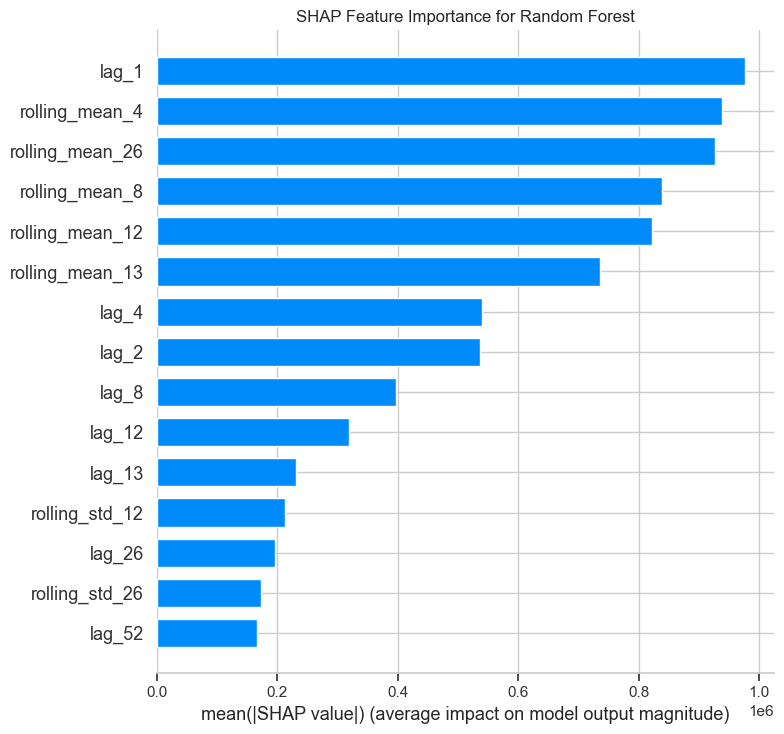

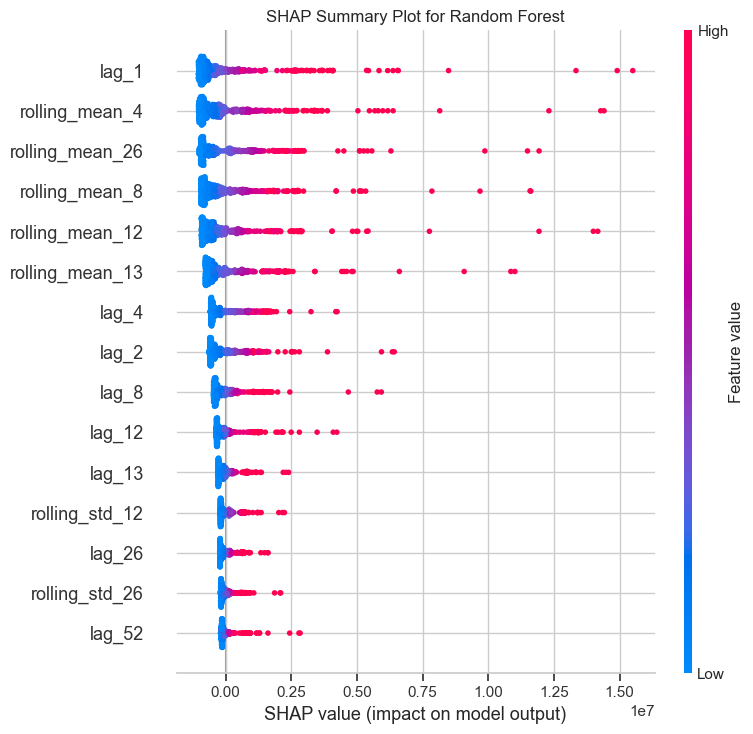

SHAP model explained: Random Forest


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import shap

# applying shap to the selected model
shap_sample_size = min(600, len(X_test))
rng = np.random.default_rng(42)
shap_index = rng.choice(len(X_test), size=shap_sample_size, replace=False)
X_shap = X_test.iloc[shap_index]

if selected_model_name == "Random Forest":
    shap_model = rf_model
elif selected_model_name == "XGBoost":
    shap_model = xgb_model
else:
    tree_scores = selection_table[selection_table["Model"].isin(["Random Forest", "XGBoost"])].copy()
    shap_model_name = tree_scores.sort_values("Overall Selection Score").iloc[0]["Model"]
    shap_model = rf_model if shap_model_name == "Random Forest" else xgb_model
    print("SHAP is shown for the best tree-based model because the selected model is not tree-based:", shap_model_name)

if selected_model_name in ["Random Forest", "XGBoost"]:
    shap_model_name = selected_model_name

shap_explainer = shap.TreeExplainer(shap_model)
shap_values = shap_explainer.shap_values(X_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=15, show=False)
plt.title(f"SHAP Feature Importance for {shap_model_name}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title(f"SHAP Summary Plot for {shap_model_name}")
plt.tight_layout()
plt.show()

print("SHAP model explained:", shap_model_name)

## LIME Explanation

In [ ]:
!pip install LIME

,Feature,Contribution
0,1293782.75 < lag_1 <= 4300933.50,-2.012865e+06
1,1279315.56 < rolling_mean_4 <= 4312492.88,-1.352444e+06
2,1273176.42 < rolling_mean_12 <= 4312839.21,-1.319549e+06
3,1271563.38 < rolling_mean_8 <= 4314583.75,-1.285653e+06
4,1274492.94 < rolling_mean_13 <= 4312094.08,-1.234432e+06
5,1272366.53 < rolling_mean_26 <= 4309669.89,-1.076578e+06
6,State_Vermont <= 0.00,8.128831e+05
7,1301878.25 < lag_2 <= 4299666.00,-8.097330e+05
8,State_Pennsylvania <= 0.00,7.794584e+05
9,Category_Sugar and sweeteners <= 0.00,7.140009e+05


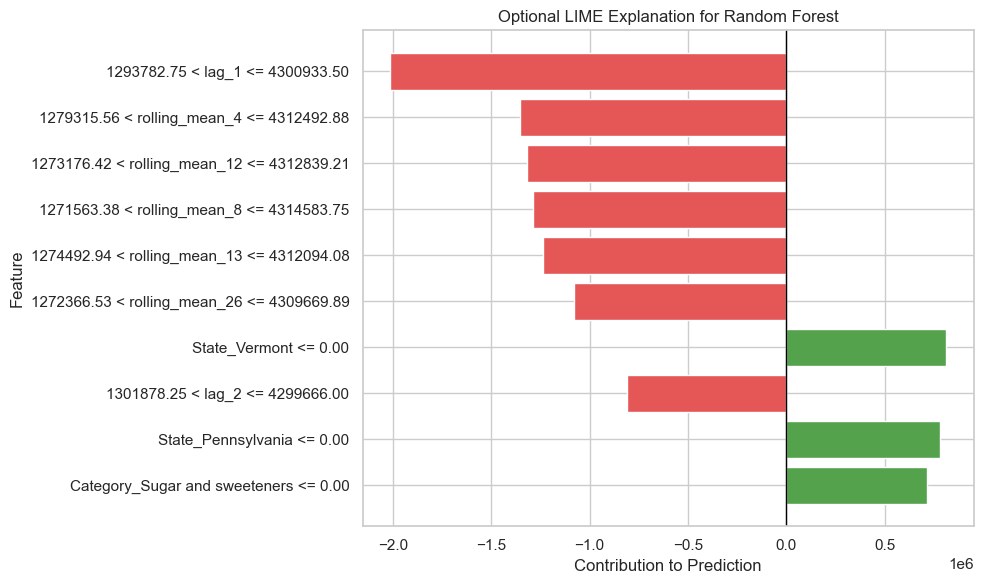

LIME model explained: Random Forest


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

# creating an lime explanation
lime_train_size = min(3000, len(X_fit))
rng = np.random.default_rng(42)
lime_train_index = rng.choice(len(X_fit), size=lime_train_size, replace=False)

if selected_model_name == "Random Forest":
    lime_predict_function = rf_model.predict
    lime_model_name = "Random Forest"
elif selected_model_name == "XGBoost":
    lime_predict_function = xgb_model.predict
    lime_model_name = "XGBoost"
elif selected_model_name == "SVR":
    lime_predict_function = svr_model.predict
    lime_model_name = "SVR"
else:
    lime_predict_function = xgb_model.predict
    lime_model_name = "XGBoost"

lime_explainer = LimeTabularExplainer(
    training_data=X_fit.iloc[lime_train_index].values,
    feature_names=list(X_fit.columns),
    mode="regression",
    random_state=42,
    discretize_continuous=True
)

lime_instance = X_test.iloc[0].values
lime_explanation = lime_explainer.explain_instance(
    lime_instance,
    lime_predict_function,
    num_features=10
)

lime_table = pd.DataFrame(lime_explanation.as_list(), columns=["Feature", "Contribution"])
display(lime_table)

lime_plot_data = lime_table.iloc[::-1]
colors = ["#54A24B" if value >= 0 else "#E45756" for value in lime_plot_data["Contribution"]]

plt.figure(figsize=(10, 6))
plt.barh(lime_plot_data["Feature"], lime_plot_data["Contribution"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title(f"LIME Explanation for {lime_model_name}")
plt.xlabel("Contribution to Prediction")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("LIME model explained:", lime_model_name)

## Selected Model Performance by State

In [37]:
import numpy as np
import pandas as pd

# calculating state-level performance for the selected model
selected_results_df = common_test_df[["Date", "State", "Category", "Actual", selected_model_name]].copy()
selected_results_df = selected_results_df.rename(columns={selected_model_name: "Predicted"})
selected_results_df["Forecast_Error"] = selected_results_df["Predicted"] - selected_results_df["Actual"]
selected_results_df["Absolute_Error"] = selected_results_df["Forecast_Error"].abs()
selected_results_df["Relative_Forecast_Error"] = selected_results_df["Forecast_Error"] / selected_results_df["Actual"]

state_performance = (
    selected_results_df.groupby("State")
    .apply(lambda x: pd.Series({
        "Rows": len(x),
        "MAE": x["Absolute_Error"].mean(),
        "WAPE": x["Absolute_Error"].sum() / x["Actual"].sum(),
        "Forecast Bias": x["Forecast_Error"].sum() / x["Actual"].sum()
    }))
    .reset_index()
    .sort_values("WAPE")
)

display(state_performance.round(4))

,State,Rows,MAE,WAPE,Forecast Bias
32,South Carolina,495.0,2.541870e+05,0.0318,0.0066
26,North Carolina,495.0,4.948245e+05,0.0323,0.0091
39,Washington,495.0,2.776408e+05,0.0326,0.0103
7,Georgia,495.0,4.959054e+05,0.0331,0.0136
15,Maryland,495.0,2.307063e+05,0.0336,0.0124
35,Texas,495.0,1.163684e+06,0.0336,0.0096
6,Florida,493.0,1.050894e+06,0.0336,-0.0024
38,Virginia,495.0,4.282330e+05,0.0347,0.0110
22,Nevada,495.0,1.445977e+05,0.0353,0.0081
4,Colorado,495.0,2.771893e+05,0.0357,0.0087


## Selected Model Performance by Product Category

In [38]:
import pandas as pd

# calculating category-level performance for the selected model
category_performance = (
    selected_results_df.groupby("Category")
    .apply(lambda x: pd.Series({
        "Rows": len(x),
        "MAE": x["Absolute_Error"].mean(),
        "WAPE": x["Absolute_Error"].sum() / x["Actual"].sum(),
        "Forecast Bias": x["Forecast_Error"].sum() / x["Actual"].sum()
    }))
    .reset_index()
    .sort_values("WAPE")
)

display(category_performance.round(4))

,Category,Rows,MAE,WAPE,Forecast Bias
1,Beverages,1935.0,6.175105e+05,0.0341,0.0128
5,Fruits,1935.0,2.391968e+05,0.0349,0.0092
3,Dairy,1928.0,2.925566e+05,0.0360,0.0039
6,Grains,1935.0,2.046296e+05,0.0363,0.0044
0,Alcohol,1935.0,1.267729e+05,0.0371,0.0041
2,Commercially prepared items,1935.0,1.260470e+06,0.0380,0.0124
7,"Meats, eggs, and nuts",1930.0,3.791894e+05,0.0387,0.0072
8,Other,1935.0,9.575740e+04,0.0427,0.0076
10,Vegetables,1935.0,4.709790e+05,0.0445,0.0044
9,Sugar and sweeteners,1935.0,2.692118e+04,0.0700,-0.0089


## Surplus and Stockout Risk Indicators

In [39]:
import numpy as np
import pandas as pd

# creating proxy risk indicators from forecast errors
selected_results_df["Proxy_Risk"] = np.select(
    [
        selected_results_df["Forecast_Error"] > 0,
        selected_results_df["Forecast_Error"] < 0,
        selected_results_df["Forecast_Error"] == 0
    ],
    [
        "Potential surplus-risk indicator",
        "Potential stockout-risk indicator",
        "No directional error"
    ],
    default="No directional error"
)

risk_summary = (
    selected_results_df.groupby("Proxy_Risk")
    .agg(
        Rows=("Proxy_Risk", "size"),
        Mean_Relative_Forecast_Error=("Relative_Forecast_Error", "mean"),
        Median_Relative_Forecast_Error=("Relative_Forecast_Error", "median"),
        Mean_Absolute_Error=("Absolute_Error", "mean")
    )
    .reset_index()
)

display(risk_summary.round(4))
display(selected_results_df.head(10).round(4))

,Proxy_Risk,Rows,Mean_Relative_Forecast_Error,Median_Relative_Forecast_Error,Mean_Absolute_Error
0,Potential stockout-risk indicator,8092,-0.0461,-0.0295,343906.5427
1,Potential surplus-risk indicator,13181,0.0469,0.0344,343962.3427


,Date,State,Category,Actual,Predicted,Forecast_Error,Absolute_Error,Relative_Forecast_Error,Proxy_Risk
0,2022-07-03,Alabama,Alcohol,3283438.0,3.106163e+06,-177274.5940,177274.5940,-0.0540,Potential stockout-risk indicator
1,2022-07-10,Alabama,Alcohol,3034812.0,3.057821e+06,23009.1220,23009.1220,0.0076,Potential surplus-risk indicator
2,2022-07-17,Alabama,Alcohol,2981848.0,3.057086e+06,75238.3429,75238.3429,0.0252,Potential surplus-risk indicator
3,2022-07-24,Alabama,Alcohol,2883954.0,3.022841e+06,138886.7889,138886.7889,0.0482,Potential surplus-risk indicator
4,2022-07-31,Alabama,Alcohol,3036129.0,3.011463e+06,-24666.4490,24666.4490,-0.0081,Potential stockout-risk indicator
5,2022-08-07,Alabama,Alcohol,2980886.0,3.009235e+06,28349.1868,28349.1868,0.0095,Potential surplus-risk indicator
6,2022-08-14,Alabama,Alcohol,2990916.0,3.010190e+06,19274.0789,19274.0789,0.0064,Potential surplus-risk indicator
7,2022-08-21,Alabama,Alcohol,2959181.0,2.979177e+06,19996.4703,19996.4703,0.0068,Potential surplus-risk indicator
8,2022-08-28,Alabama,Alcohol,2983772.0,2.982758e+06,-1014.0105,1014.0105,-0.0003,Potential stockout-risk indicator
9,2022-09-04,Alabama,Alcohol,3272838.0,3.001263e+06,-271575.4718,271575.4718,-0.0830,Potential stockout-risk indicator


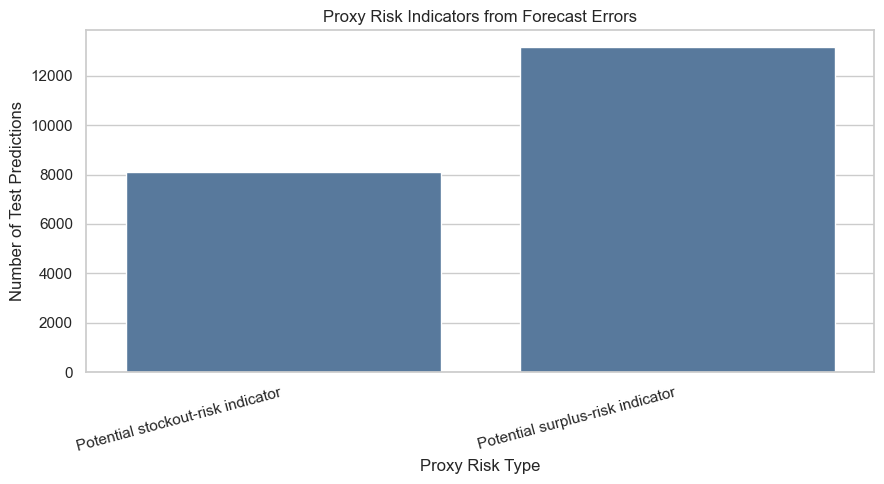

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# plotting proxy risk counts
plt.figure(figsize=(9, 5))
sns.barplot(data=risk_summary, x="Proxy_Risk", y="Rows", color="#4C78A8")
plt.title("Proxy Risk Indicators from Forecast Errors")
plt.xlabel("Proxy Risk Type")
plt.ylabel("Number of Test Predictions")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()